In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%matplotlib inline

In [3]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [4]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

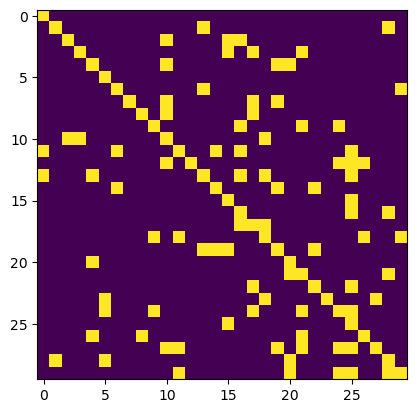

In [5]:
plt.imshow(A!=0)

In [6]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j]) 
        noise[i] = yy
    return noise 
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [7]:
noise.shape

(30, 5000)

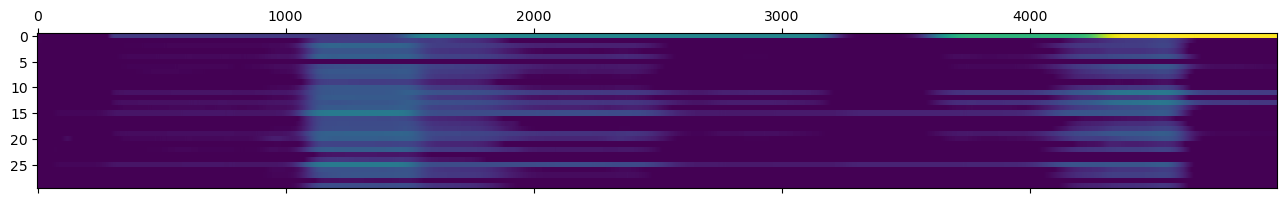

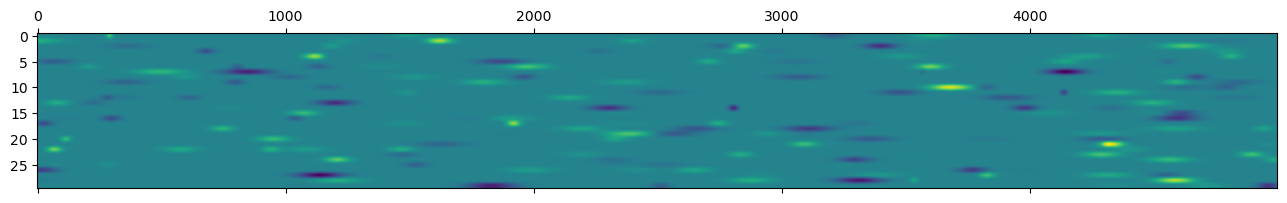

In [8]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + 0.05*np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(1, 8, 1), 1, 1000
alpha, beta = 0.01, 0.001

In [10]:
%%time
metrics = np.zeros((7,4))
infs = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
    gcstar.fit(X, verbose = 1)
    
    infs.append(gcstar.get_connectivity_matrix(simulation=True))
    gcstar.plot_extended_connectivity_matrix()
    gcstar.compute_confusion_matrix(A, simulation = True)
    metrics[i] =  gcstar.compute_metrics()

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


1 pasts


C:\Users\sadiq\Documents\GC-extension\examples\..\src\d_CSL.py:32: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  corr_1 = np.corrcoef(x, y)[1, 0]
INFO:src.d_CSL:Step 1/1800 (0.06% complete)
INFO:src.d_CSL:Step 2/1800 (0.11% complete)
INFO:src.d_CSL:Step 3/1800 (0.17% complete)
INFO:src.d_CSL:Step 4/1800 (0.22% complete)
INFO:src.d_CSL:Step 5/1800 (0.28% complete)
INFO:src.d_CSL:Step 6/1800 (0.33% complete)
INFO:src.d_CSL:Step 7/1800 (0.39% complete)
INFO:src.d_CSL:Step 8/1800 (0.44% complete)
INFO:src.d_CSL:Step 9/1800 (0.50% complete)
INFO:src.d_CSL:Step 10/1800 (0.56% complete)
INFO:src.d_CSL:Step 11/1800 (0.61% complete)
INFO:src.d_CSL:Step 12/1800 (0.67% complete)
INFO:src.d_CSL:Step 13/1800 (0.72% complete)
INFO:src.d_CSL:Step 14/1800 (0.78% complete)
INFO:src.d_CSL:Step 15/1800 (0.83% complete)
INFO:src.d_CSL:Step 16/1800 (0.89% complete)
INFO:src.d_CSL:Step 17/1800 (0.94% complete)
INFO:src.d_CSL:Step 18/1800 (1.00% complete)
I

INFO:src.d_CSL:Step 177/1800 (9.83% complete)
INFO:src.d_CSL:Step 178/1800 (9.89% complete)
INFO:src.d_CSL:Step 179/1800 (9.94% complete)
INFO:src.d_CSL:Step 180/1800 (10.00% complete)
INFO:src.d_CSL:Step 181/1800 (10.06% complete)
INFO:src.d_CSL:Step 182/1800 (10.11% complete)
INFO:src.d_CSL:Step 183/1800 (10.17% complete)
INFO:src.d_CSL:Step 184/1800 (10.22% complete)
INFO:src.d_CSL:Step 185/1800 (10.28% complete)
INFO:src.d_CSL:Step 186/1800 (10.33% complete)
INFO:src.d_CSL:Step 187/1800 (10.39% complete)
INFO:src.d_CSL:Step 188/1800 (10.44% complete)
INFO:src.d_CSL:Step 189/1800 (10.50% complete)
INFO:src.d_CSL:Step 190/1800 (10.56% complete)
INFO:src.d_CSL:Step 191/1800 (10.61% complete)
INFO:src.d_CSL:Step 192/1800 (10.67% complete)
INFO:src.d_CSL:Step 193/1800 (10.72% complete)
INFO:src.d_CSL:Step 194/1800 (10.78% complete)
INFO:src.d_CSL:Step 195/1800 (10.83% complete)
INFO:src.d_CSL:Step 196/1800 (10.89% complete)
INFO:src.d_CSL:Step 197/1800 (10.94% complete)
INFO:src.d_CSL:S

INFO:src.d_CSL:Step 352/1800 (19.56% complete)
INFO:src.d_CSL:Step 353/1800 (19.61% complete)
INFO:src.d_CSL:Step 354/1800 (19.67% complete)
INFO:src.d_CSL:Step 355/1800 (19.72% complete)
INFO:src.d_CSL:Step 356/1800 (19.78% complete)
INFO:src.d_CSL:Step 357/1800 (19.83% complete)
INFO:src.d_CSL:Step 358/1800 (19.89% complete)
INFO:src.d_CSL:Step 359/1800 (19.94% complete)
INFO:src.d_CSL:Step 360/1800 (20.00% complete)
INFO:src.d_CSL:Step 361/1800 (20.06% complete)
INFO:src.d_CSL:Step 362/1800 (20.11% complete)
INFO:src.d_CSL:Step 363/1800 (20.17% complete)
INFO:src.d_CSL:Step 364/1800 (20.22% complete)
INFO:src.d_CSL:Step 365/1800 (20.28% complete)
INFO:src.d_CSL:Step 366/1800 (20.33% complete)
INFO:src.d_CSL:Step 367/1800 (20.39% complete)
INFO:src.d_CSL:Step 368/1800 (20.44% complete)
INFO:src.d_CSL:Step 369/1800 (20.50% complete)
INFO:src.d_CSL:Step 370/1800 (20.56% complete)
INFO:src.d_CSL:Step 371/1800 (20.61% complete)
INFO:src.d_CSL:Step 372/1800 (20.67% complete)
INFO:src.d_CS

...

INFO:src.d_CSL:Step 1222/1800 (67.89% complete)
INFO:src.d_CSL:Step 1223/1800 (67.94% complete)
INFO:src.d_CSL:Step 1224/1800 (68.00% complete)
INFO:src.d_CSL:Step 1225/1800 (68.06% complete)
INFO:src.d_CSL:Step 1226/1800 (68.11% complete)
INFO:src.d_CSL:Step 1227/1800 (68.17% complete)
INFO:src.d_CSL:Step 1228/1800 (68.22% complete)
INFO:src.d_CSL:Step 1229/1800 (68.28% complete)
INFO:src.d_CSL:Step 1230/1800 (68.33% complete)
INFO:src.d_CSL:Step 1231/1800 (68.39% complete)
INFO:src.d_CSL:Step 1232/1800 (68.44% complete)
INFO:src.d_CSL:Step 1233/1800 (68.50% complete)
INFO:src.d_CSL:Step 1234/1800 (68.56% complete)
INFO:src.d_CSL:Step 1235/1800 (68.61% complete)
INFO:src.d_CSL:Step 1236/1800 (68.67% complete)
INFO:src.d_CSL:Step 1237/1800 (68.72% complete)
INFO:src.d_CSL:Step 1238/1800 (68.78% complete)
INFO:src.d_CSL:Step 1239/1800 (68.83% complete)
INFO:src.d_CSL:Step 1240/1800 (68.89% complete)
INFO:src.d_CSL:Step 1241/1800 (68.94% complete)
INFO:src.d_CSL:Step 1242/1800 (69.00% co

INFO:src.d_CSL:Step 1393/1800 (77.39% complete)
INFO:src.d_CSL:Step 1394/1800 (77.44% complete)
INFO:src.d_CSL:Step 1395/1800 (77.50% complete)
INFO:src.d_CSL:Step 1396/1800 (77.56% complete)
INFO:src.d_CSL:Step 1397/1800 (77.61% complete)
INFO:src.d_CSL:Step 1398/1800 (77.67% complete)
INFO:src.d_CSL:Step 1399/1800 (77.72% complete)
INFO:src.d_CSL:Step 1400/1800 (77.78% complete)
INFO:src.d_CSL:Step 1401/1800 (77.83% complete)
INFO:src.d_CSL:Step 1402/1800 (77.89% complete)
INFO:src.d_CSL:Step 1403/1800 (77.94% complete)
INFO:src.d_CSL:Step 1404/1800 (78.00% complete)
INFO:src.d_CSL:Step 1405/1800 (78.06% complete)
INFO:src.d_CSL:Step 1406/1800 (78.11% complete)
INFO:src.d_CSL:Step 1407/1800 (78.17% complete)
INFO:src.d_CSL:Step 1408/1800 (78.22% complete)
INFO:src.d_CSL:Step 1409/1800 (78.28% complete)
INFO:src.d_CSL:Step 1410/1800 (78.33% complete)
INFO:src.d_CSL:Step 1411/1800 (78.39% complete)
INFO:src.d_CSL:Step 1412/1800 (78.44% complete)
INFO:src.d_CSL:Step 1413/1800 (78.50% co

INFO:src.d_CSL:Step 1564/1800 (86.89% complete)
INFO:src.d_CSL:Step 1565/1800 (86.94% complete)
INFO:src.d_CSL:Step 1566/1800 (87.00% complete)
INFO:src.d_CSL:Step 1567/1800 (87.06% complete)
INFO:src.d_CSL:Step 1568/1800 (87.11% complete)
INFO:src.d_CSL:Step 1569/1800 (87.17% complete)
INFO:src.d_CSL:Step 1570/1800 (87.22% complete)
INFO:src.d_CSL:Step 1571/1800 (87.28% complete)
INFO:src.d_CSL:Step 1572/1800 (87.33% complete)
INFO:src.d_CSL:Step 1573/1800 (87.39% complete)
INFO:src.d_CSL:Step 1574/1800 (87.44% complete)
INFO:src.d_CSL:Step 1575/1800 (87.50% complete)
INFO:src.d_CSL:Step 1576/1800 (87.56% complete)
INFO:src.d_CSL:Step 1577/1800 (87.61% complete)
INFO:src.d_CSL:Step 1578/1800 (87.67% complete)
INFO:src.d_CSL:Step 1579/1800 (87.72% complete)
INFO:src.d_CSL:Step 1580/1800 (87.78% complete)
INFO:src.d_CSL:Step 1581/1800 (87.83% complete)
INFO:src.d_CSL:Step 1582/1800 (87.89% complete)
INFO:src.d_CSL:Step 1583/1800 (87.94% complete)
INFO:src.d_CSL:Step 1584/1800 (88.00% co

INFO:src.d_CSL:Step 1735/1800 (96.39% complete)
INFO:src.d_CSL:Step 1736/1800 (96.44% complete)
INFO:src.d_CSL:Step 1737/1800 (96.50% complete)
INFO:src.d_CSL:Step 1738/1800 (96.56% complete)
INFO:src.d_CSL:Step 1739/1800 (96.61% complete)
INFO:src.d_CSL:Step 1740/1800 (96.67% complete)
INFO:src.d_CSL:Step 1741/1800 (96.72% complete)
INFO:src.d_CSL:Step 1742/1800 (96.78% complete)
INFO:src.d_CSL:Step 1743/1800 (96.83% complete)
INFO:src.d_CSL:Step 1744/1800 (96.89% complete)
INFO:src.d_CSL:Step 1745/1800 (96.94% complete)
INFO:src.d_CSL:Step 1746/1800 (97.00% complete)
INFO:src.d_CSL:Step 1747/1800 (97.06% complete)
INFO:src.d_CSL:Step 1748/1800 (97.11% complete)
INFO:src.d_CSL:Step 1749/1800 (97.17% complete)
INFO:src.d_CSL:Step 1750/1800 (97.22% complete)
INFO:src.d_CSL:Step 1751/1800 (97.28% complete)
INFO:src.d_CSL:Step 1752/1800 (97.33% complete)
INFO:src.d_CSL:Step 1753/1800 (97.39% complete)
INFO:src.d_CSL:Step 1754/1800 (97.44% complete)
INFO:src.d_CSL:Step 1755/1800 (97.50% co

ValueError: Found input variables with inconsistent numbers of samples: [9998, 4999]

In [11]:
metrics

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

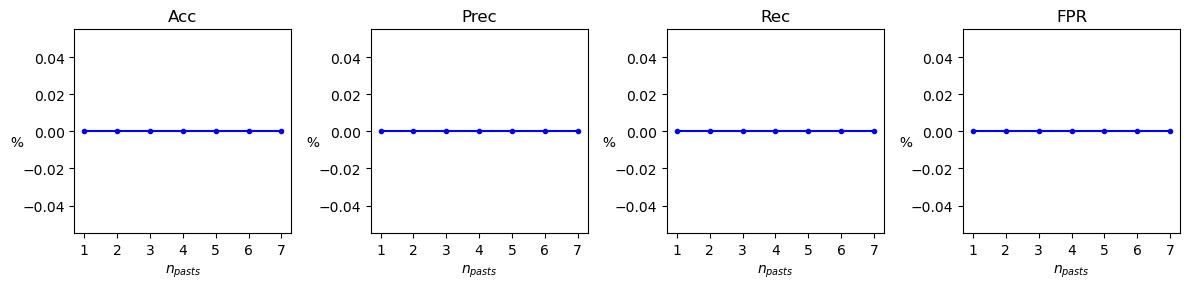

In [12]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

In [13]:
def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)



In [14]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(A.T, el))
    plt.title(f'{i+1} pasts')

In [15]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FN_inf],
                     [FP_inf,TN_inf]])


IndexError: list index out of range

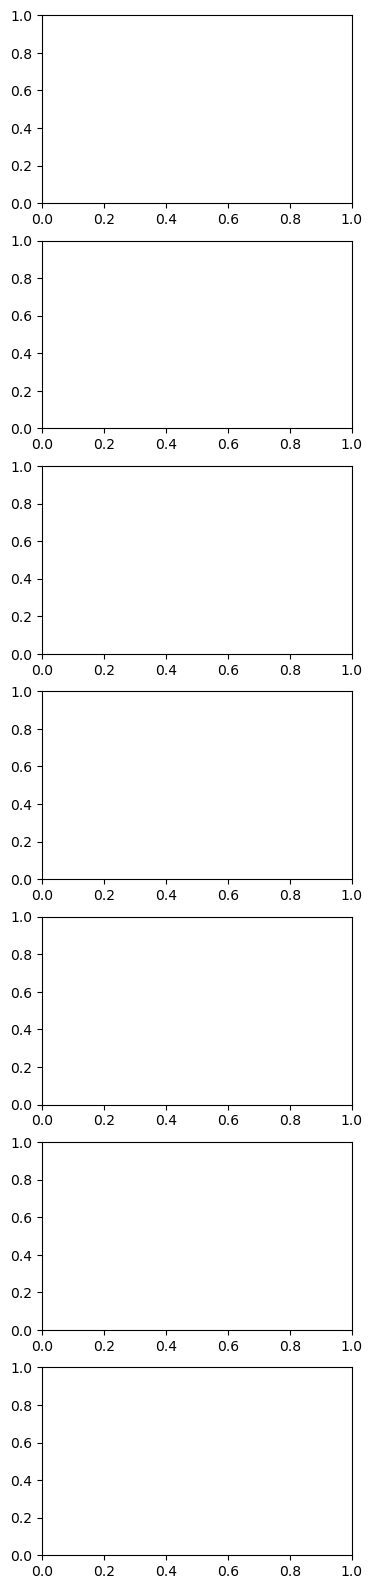

In [16]:
%matplotlib inline
import seaborn as sns
fig,axes = plt.subplots(7, 1, figsize=(4,20))
for i, ax in enumerate(axes):
    conf = confusion_matrix(infs[i], A.T)
    print(conf)
    g1 = sns.heatmap(conf, annot=True, ax=ax)